In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from huggingface_hub import login
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from vllm import LLM, SamplingParams

import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-12-05 00:40:35.252900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-05 00:40:35.265731: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-05 00:40:35.269599: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-05 00:40:35.279226: I tensorflow/core/platfor

INFO 12-05 00:40:36 [__init__.py:243] No platform detected, vLLM is running on UnspecifiedPlatform


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
model_id = "google/bigbird-roberta-base"

classification_type = "CLS embedding similarity without fine-tuning"
model_name = "bigbird-roberta-base"
developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "transformer"

test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"

Load environment variables
Get access to HuggingFace

In [6]:
load_dotenv(env_path)
huggingface_acess_token = os.getenv("huggingface_jp")

Connect to databricks for logging results

In [7]:
w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")

Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


What are GPU are the experiments run on

In [8]:
!nvidia-smi

/usr/bin/sh: line 1: nvidia-smi: command not found


In [9]:
running_on_gpu = torch.cuda.is_available()

In [10]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [11]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

106

In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Classification threshold constant specification

In [13]:
thresholds = [x/1000 for x in range(940, 980)]

# Load dataset

In [14]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:01<00:00, 515MB/s] 


Successfully loaded 19999 items.


In [15]:
test_data_df = pd.DataFrame(test_data)
print(test_data_df.head())

                                     id  \
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   
1  b9326101-6352-56dd-9d1b-1f41466897b7   
2  e2ac4453-bf54-53f2-bf68-6caae6aacded   
3  a5e9a289-0999-5764-b597-dc1bf8c21ede   
4  cb4054b1-d422-58d6-a137-dcfc70100df6   

                                                pair   same  
0  [talk because they hadnt been exposed to commu...   True  
1  [Zazuki nodded his head and got to his feet, k...   True  
2  [Oh we did lots of special things On Christmas...  False  
3  [Hey now, at least Shido brings home some mone...   True  
4  [It was a mere five minutes walk from third ye...   True  


In [16]:
test_data_df = pd.DataFrame(test_data)
print(test_data_df.head())

                                     id  \
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   
1  b9326101-6352-56dd-9d1b-1f41466897b7   
2  e2ac4453-bf54-53f2-bf68-6caae6aacded   
3  a5e9a289-0999-5764-b597-dc1bf8c21ede   
4  cb4054b1-d422-58d6-a137-dcfc70100df6   

                                                pair   same  
0  [talk because they hadnt been exposed to commu...   True  
1  [Zazuki nodded his head and got to his feet, k...   True  
2  [Oh we did lots of special things On Christmas...  False  
3  [Hey now, at least Shido brings home some mone...   True  
4  [It was a mere five minutes walk from third ye...   True  


# Set up model

Log in to huggingface

In [17]:
login(huggingface_acess_token)

Load the model

In [18]:
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/846k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

Set the processing to GPU

In [19]:
device = torch.device("cuda" if running_on_gpu else "cpu")
model = model.to(device)

In [20]:
model.eval()

BigBirdModel(
  (embeddings): BigBirdEmbeddings(
    (word_embeddings): Embedding(50358, 768, padding_idx=0)
    (position_embeddings): Embedding(4096, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BigBirdEncoder(
    (layer): ModuleList(
      (0-11): 12 x BigBirdLayer(
        (attention): BigBirdAttention(
          (self): BigBirdBlockSparseAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): BigBirdSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
    

# Evaluate model

Evaluate model function

In [21]:
def compute_similarities(test_data_df, model):
    start_time = time.time()
    verification_results = []
    
    def get_embedding(text: str):
        encoded = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding= False,
            max_length=4096,
        ).to(device)
        
        with torch.no_grad():
            output = model(**encoded)
            cls_emb = output.last_hidden_state[:, 0, :]
            embedding = F.normalize(cls_emb, p=2, dim=1)
        return embedding.cpu()

    for i in tqdm(test_data_df.index, desc="Processing rows"):
        resulting_df_row = {}
        resulting_df_row['id']  = test_data_df.loc[i, 'id']
        resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
        text1 = test_data_df.loc[i, 'pair'][0]
        text2 = test_data_df.loc[i, 'pair'][1]
        
        text1_embedding = get_embedding(text1)
        text2_embedding = get_embedding(text2)

        cosine_similarity_score = cosine_similarity(text1_embedding, text2_embedding)


        sim_torch = F.cosine_similarity(text1_embedding, text2_embedding).item()        
        resulting_df_row['cosine_similarity'] = cosine_similarity_score
        verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)
    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Compute similarities

In [22]:
result_df = compute_similarities(test_data_df, model)
result_df.head()

Processing rows:   0%|          | 0/100 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

Processing rows: 100%|██████████| 100/100 [15:31<00:00,  9.31s/it]

--- Execution Time: 931.48 seconds ---


,id,actual_result,cosine_similarity
0,c28e8b03-c02a-5184-b58a-12dd28b8ca74,True,[[0.9830364]]
1,b9326101-6352-56dd-9d1b-1f41466897b7,True,[[0.97382987]]
2,e2ac4453-bf54-53f2-bf68-6caae6aacded,False,[[0.98771286]]
3,a5e9a289-0999-5764-b597-dc1bf8c21ede,True,[[0.9855449]]
4,cb4054b1-d422-58d6-a137-dcfc70100df6,True,[[0.9678544]]


Evaluation function

In [23]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Optimal threshold search

In [24]:
def evaluate_classification_thresholds(result_df, classification_thresholds):
    results = []
    y_embeddings = result_df['cosine_similarity']
    y_true = result_df['actual_result']
    for threshold in thresholds:
        y_pred = (result_df["cosine_similarity"] >= threshold).astype(int)
        accuracy, precision, recall, f1 = evaluate_results(y_true, y_pred)
        results.append({
            "threshold": threshold,
            "accuracy" : accuracy,
            "precision" : precision,
            "recall" : recall,
            "f1" : f1
        })
    return pd.DataFrame(results)

Evaluate thresholds

In [25]:
threshold_results_df = evaluate_classification_thresholds(result_df, thresholds)

Create histogram of F1 score for different thresholds

In [26]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], marker="o", linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

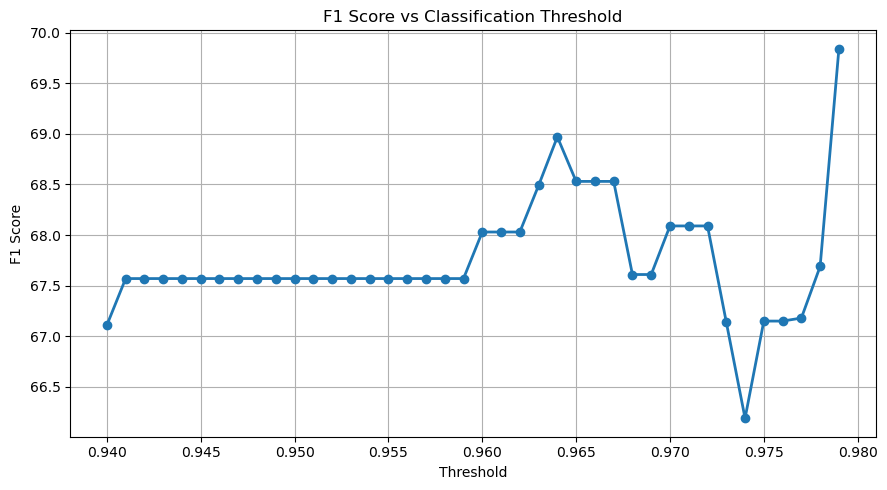

In [27]:
f1_threshold_histogram_fig = plot_f1_vs_threshold(threshold_results_df)
f1_threshold_histogram_fig.show()

Print top 5 results

In [28]:
sorted_threshold_results_df = threshold_results_df.sort_values("f1", ascending=False)
top5_results = sorted_threshold_results_df.head(5)

print("Top 5 thresholds by F1:")
print(top5_results)

Top 5 thresholds by F1:
    threshold  accuracy  precision  recall     f1
39      0.979      62.0      57.89    88.0  69.84
24      0.964      55.0      52.63   100.0  68.97
27      0.967      55.0      52.69    98.0  68.53
26      0.966      55.0      52.69    98.0  68.53
25      0.965      55.0      52.69    98.0  68.53


Pick the best result and compute y_pred

In [29]:
top_threshold = top5_results.iloc[0]["threshold"]

y_true = result_df['actual_result']
y_pred = (result_df["cosine_similarity"] >= top_threshold).astype(int).values

best_accuracy, best_precision, best_recall, best_f1 = evaluate_results(y_true, y_pred)

Create the confusion matrix

Text(0.5, 1.0, 'Confusion Matrix: google/bigbird-roberta-base')

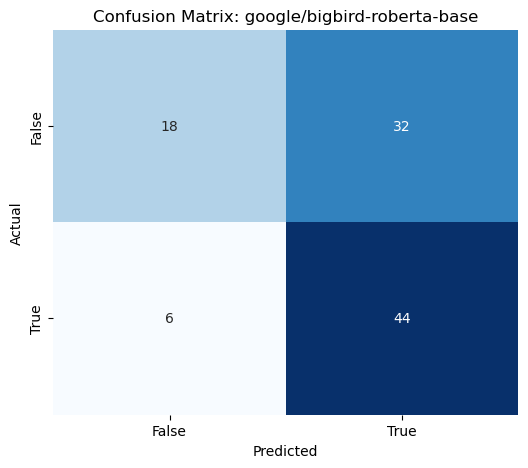

In [30]:
labels = [False, True] 
cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=labels, 
            yticklabels=labels, 
            ax=ax,
            cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {model_id}')

Log model information + metrics + results table + confusion matrix

In [31]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{model_name}_results"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("model_id ", model_id )
    mlflow.log_param("classification_type", classification_type)
    
    mlflow.log_param("classification_thresholds", thresholds)

    mlflow.log_table(data=result_df, artifact_file="embedding_similarity_results.json")
    mlflow.log_table(data=threshold_results_df, artifact_file="results_for_different_thresholds.json")
    
    mlflow.log_metric("top_result_accuracy", best_accuracy)
    mlflow.log_metric("top_precision", best_precision)
    mlflow.log_metric("top_recall", best_recall)
    mlflow.log_metric("top_f1", best_f1)

    mlflow.log_figure(f1_threshold_histogram_fig, "f1_results_threshold_histogram.png")
    mlflow.log_figure(cm_fig, "confusion_matrix.png")

🏃 View run JP_bigbird-roberta-base_results at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/0bcad631e2cd4b4ea6690ba8b50bc639
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040
